In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import re

# Cargar CSV
df = pd.read_csv("/content/drive/MyDrive/TFG/train.csv")

# Extraer patient_id
def get_patient_id(path):
    m = re.search(r"patient(\d+)", path)
    return int(m.group(1)) if m else None

df["patient_id"] = df["Path"].apply(get_patient_id)

# Subconjunto (Batch 2)
df_batch2 = df[df["patient_id"] <= 21513].copy()

print("Total subconjunto:", len(df_batch2))

# Filtrar imágenes frontales
df_frontal = df_batch2[df_batch2["Frontal/Lateral"] == "Frontal"].copy()

print("Imágenes frontales:", len(df_frontal))

# Filtrar proyección PA
df_pa = df_frontal[df_frontal["AP/PA"] == "PA"].copy()

print("Imágenes PA:", len(df_pa))

Mounted at /content/drive
Total subconjunto: 89484
Imágenes frontales: 70890
Imágenes PA: 18244


In [ ]:
#Selección de etiquetas

cols = [
    "No Finding",
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

df_labels = df_pa[cols].copy()

In [ ]:
label_cols = [
    "No Finding",
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

base_cols = ["Path", "patient_id"] + label_cols

df_selected = df_pa[base_cols].copy()

# Casos limpios: ninguna etiqueta con -1
df_train_clean = df_selected[(df_selected[label_cols] != -1).all(axis=1)].copy()

# Casos inciertos: al menos una etiqueta con -1
df_train_uncertain = df_selected[(df_selected[label_cols] == -1).any(axis=1)].copy()

print("Conjunto limpio:", len(df_train_clean))
print("Conjunto incierto:", len(df_train_uncertain))

Conjunto limpio: 15490
Conjunto incierto: 2754


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

label_cols = [
    "No Finding",
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

base_cols = ["Path", "patient_id"] + label_cols

df_selected = df_pa[base_cols].copy()

# División por paciente
patients = df_selected["patient_id"].unique()

train_patients, valid_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42
)

df_train = df_selected[df_selected["patient_id"].isin(train_patients)].copy()
df_valid = df_selected[df_selected["patient_id"].isin(valid_patients)].copy()

print("Radiografías train:", len(df_train))
print("Radiografías valid:", len(df_valid))
print("Pacientes train:", df_train["patient_id"].nunique())
print("Pacientes valid:", df_valid["patient_id"].nunique())

Radiografías train: 14607
Radiografías valid: 3637
Pacientes train: 10242
Pacientes valid: 2561


In [ ]:
tabla_division = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación"],
    "Radiografías": [len(df_train), len(df_valid)],
    "Pacientes": [df_train["patient_id"].nunique(), df_valid["patient_id"].nunique()]
})

tabla_division

,Conjunto,Radiografías,Pacientes
0,Entrenamiento,14607,10242
1,Validación,3637,2561


In [ ]:
datos_train = []

for c in label_cols:
    datos_train.append({
        "Clase": c,
        "Presente_train": (df_train[c] == 1).sum(),
        "Incierto_train": (df_train[c] == -1).sum()
    })

tabla_train_patologias = pd.DataFrame(datos_train)
tabla_train_patologias

,Clase,Presente_train,Incierto_train
0,No Finding,2628,0
1,Pneumothorax,914,200
2,Edema,833,401
3,Pleural Effusion,3996,909
4,Enlarged Cardiomediastinum,698,951


In [ ]:
datos_valid = []

for c in label_cols:
    datos_valid.append({
        "Clase": c,
        "Presente_valid": (df_valid[c] == 1).sum(),
        "Incierto_valid": (df_valid[c] == -1).sum()
    })

tabla_valid_patologias = pd.DataFrame(datos_valid)
tabla_valid_patologias

,Clase,Presente_valid,Incierto_valid
0,No Finding,722,0
1,Pneumothorax,218,41
2,Edema,201,116
3,Pleural Effusion,984,206
4,Enlarged Cardiomediastinum,179,236


In [ ]:
datos_combinados = []

for c in label_cols:
    datos_combinados.append({
        "Clase": c,
        "Presente_train": (df_train[c] == 1).sum(),
        "Incierto_train": (df_train[c] == -1).sum(),
        "Presente_valid": (df_valid[c] == 1).sum(),
        "Incierto_valid": (df_valid[c] == -1).sum()
    })

tabla_patologias_division = pd.DataFrame(datos_combinados)
tabla_patologias_division

,Clase,Presente_train,Incierto_train,Presente_valid,Incierto_valid
0,No Finding,2628,0,722,0
1,Pneumothorax,914,200,218,41
2,Edema,833,401,201,116
3,Pleural Effusion,3996,909,984,206
4,Enlarged Cardiomediastinum,698,951,179,236


In [ ]:
urgent_cols = [
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

# Crear variable urgente
df_train["urgent"] = (df_train[urgent_cols] == 1).any(axis=1).astype(int)
df_valid["urgent"] = (df_valid[urgent_cols] == 1).any(axis=1).astype(int)

# Contar distribución
train_counts = df_train["urgent"].value_counts()
valid_counts = df_valid["urgent"].value_counts()

tabla_urgente = pd.DataFrame({
    "Conjunto": ["Train", "Valid"],
    "No urgente (0)": [train_counts.get(0, 0), valid_counts.get(0, 0)],
    "Urgente (1)": [train_counts.get(1, 0), valid_counts.get(1, 0)],
})

tabla_urgente["Total"] = tabla_urgente["No urgente (0)"] + tabla_urgente["Urgente (1)"]

tabla_urgente

,Conjunto,No urgente (0),Urgente (1),Total
0,Train,9138,5469,14607
1,Valid,2294,1343,3637


In [ ]:
# Filas con al menos un -1
train_uncertain_mask = (df_train[urgent_cols] == -1).any(axis=1)
valid_uncertain_mask = (df_valid[urgent_cols] == -1).any(axis=1)

# Conteos
tabla_incertidumbre = pd.DataFrame({
    "Conjunto": ["Train", "Valid"],
    "Limpio": [
        (~train_uncertain_mask).sum(),
        (~valid_uncertain_mask).sum()
    ],
    "Incierto": [
        train_uncertain_mask.sum(),
        valid_uncertain_mask.sum()
    ]
})

tabla_incertidumbre["Total"] = tabla_incertidumbre["Limpio"] + tabla_incertidumbre["Incierto"]

tabla_incertidumbre

,Conjunto,Limpio,Incierto,Total
0,Train,12399,2208,14607
1,Valid,3091,546,3637


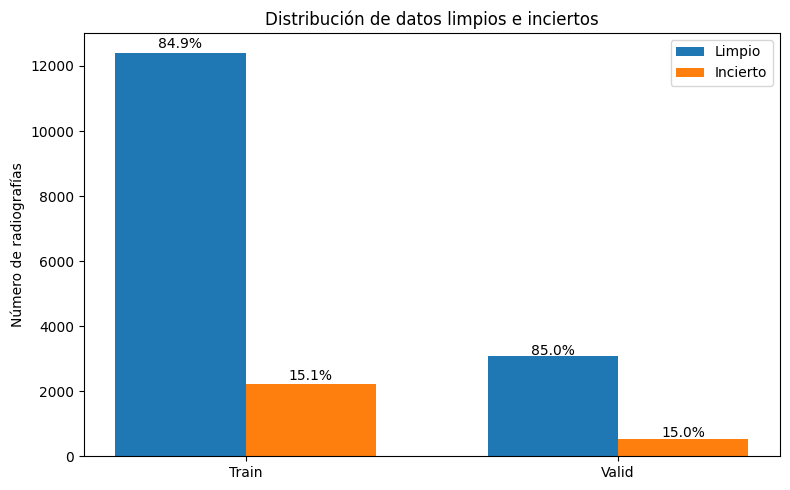

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Train", "Valid"]
limpio = tabla_incertidumbre["Limpio"].values
incierto = tabla_incertidumbre["Incierto"].values
total = tabla_incertidumbre["Total"].values

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

bars_limpio = plt.bar(x - width/2, limpio, width, label="Limpio")
bars_incierto = plt.bar(x + width/2, incierto, width, label="Incierto")

plt.xticks(x, labels)
plt.ylabel("Número de radiografías")
plt.title("Distribución de datos limpios e inciertos")
plt.legend()

# 🔥 Añadir porcentajes
for i in range(len(labels)):
    # Limpio
    pct_limpio = (limpio[i] / total[i]) * 100
    plt.text(
        x[i] - width/2,
        limpio[i] + total[i]*0.01,
        f"{pct_limpio:.1f}%",
        ha='center'
    )

    # Incierto
    pct_incierto = (incierto[i] / total[i]) * 100
    plt.text(
        x[i] + width/2,
        incierto[i] + total[i]*0.01,
        f"{pct_incierto:.1f}%",
        ha='center'
    )

plt.tight_layout()
plt.show()

In [ ]:
#Guardamos el Drive el archivo

df_selected.to_csv("/content/drive/MyDrive/TFG/df_selected.csv", index=False)

In [ ]:
import os

os.listdir("/content/drive/MyDrive/TFG")

['train.csv',
 'valid.csv',
 'valid',
 'valid_clean_images.zip',
 'train_clean_images.zip',
 'df_train_clean.csv',
 'df_valid_uncertain.csv',
 'df_valid_clean.csv',
 'df_selected.csv',
 'df_train_uncertain.csv',
 'model_resnet50.pth',
 'train_losses.csv',
 'metricas_modelo.csv',
 'all_labels.npy',
 'all_preds.npy',
 'all_probs.npy',
 'cv10_resnet50']

In [ ]:
# Separación final de subconjuntos limpios e inciertos

df_train_clean = df_train[~train_uncertain_mask].copy()
df_train_uncertain = df_train[train_uncertain_mask].copy()

df_valid_clean = df_valid[~valid_uncertain_mask].copy()
df_valid_uncertain = df_valid[valid_uncertain_mask].copy()

print("Train clean:", len(df_train_clean))
print("Train uncertain:", len(df_train_uncertain))
print("Valid clean:", len(df_valid_clean))
print("Valid uncertain:", len(df_valid_uncertain))

Train clean: 12399
Train uncertain: 2208
Valid clean: 3091
Valid uncertain: 546


In [ ]:
df_train_clean.to_csv("/content/drive/MyDrive/TFG/df_train_clean.csv", index=False)
df_train_uncertain.to_csv("/content/drive/MyDrive/TFG/df_train_uncertain.csv", index=False)
df_valid_clean.to_csv("/content/drive/MyDrive/TFG/df_valid_clean.csv", index=False)
df_valid_uncertain.to_csv("/content/drive/MyDrive/TFG/df_valid_uncertain.csv", index=False)

In [ ]:
#Descomprimimos las carpetas train y valid que contienen las imagenes a utilizar

!unzip "/content/drive/MyDrive/TFG/train_clean_images.zip" -d "/content/"

!unzip "/content/drive/MyDrive/TFG/valid_clean_images.zip" -d "/content/"

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: /content/valid_clean_images/patient08708/study2/view1_frontal.jpg  
   creating: /content/valid_clean_images/patient08708/study3/
  inflating: /content/valid_clean_images/patient08708/study3/view1_frontal.jpg  
   creating: /content/valid_clean_images/patient08719/
   creating: /content/valid_clean_images/patient08719/study1/
  inflating: /content/valid_clean_images/patient08719/study1/view1_frontal.jpg  
   creating: /content/valid_clean_images/patient08734/
   creating: /content/valid_clean_images/patient08734/study1/
  inflating: /content/valid_clean_images/patient08734/study1/view1_frontal.jpg  
   creating: /content/valid_clean_images/patient08747/
   creating: /content/valid_clean_images/patient08747/study14/
  inflating: /content/valid_clean_images/patient08747/study14/view1_frontal.jpg  
   creating: /content/valid_clean_images/patient08747/study9/
  inflating: /content/valid_clean_images/patient08747/stu

In [ ]:
train_counts_clean = df_train["urgent"].value_counts()
valid_counts_clean = df_valid["urgent"].value_counts()

print(train_counts_clean)
print(valid_counts_clean)

urgent
0    9138
1    5469
Name: count, dtype: int64
urgent
0    2294
1    1343
Name: count, dtype: int64
